# Keystone test: do pairing heads bring INPUT info to the OUTPUT position?

Hypothesis: pairing heads co-locate each demo's **input** at its **output position**, so a
downstream head can read the (input, output) pair and extract the transform.

Test: can a linear probe recover the demo's **input token id** from the residual at that
demo's **output position**? And does that decodability **drop when pairing heads are ablated**?
- decodable, and DROPS under pairing ablation  -> pairing heads carry input -> output. (hypothesis ✓)
- decodable regardless of ablation             -> input gets there some other way.
- not decodable                                -> input identity isn't at the output position at all.

This tests *decodability* (not variance), so it can find input signal even though the PCA
write-variance was position-dominated. Run on nonce/arith. `experiments/interplay/`.

In [1]:
import os, sys, pickle
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

import experiments.pairing._common as C
from data.loaders import load_dataset
from utils.heads import select_scope, make_ablation_hooks
from utils.positions import find_per_demo_positions_robust
sns.set_context('notebook')

## Config

In [2]:
DATASET   = 'nonce+arithmetic'
HEAD_PCT  = 10
SCOPE     = 'pooled'
N_PROMPTS = 30
PROBE_LAYER = 13          # residual layer at the output position to probe (try a few)
CUDA      = '0'
ds_tag = DATASET.replace('+','_')

model = C.load_model(cuda_visible=CUDA)
n_layers = model.cfg.n_layers
splits = load_dataset(DATASET)
tasks = sorted(splits.keys())
cache = f'../../results/head_sets_{ds_tag}_pct{HEAD_PCT}.pkl'
with open(cache,'rb') as f: ms = pickle.load(f)
pairing = select_scope(ms, SCOPE)['pairing']
rand_heads = select_scope(ms, SCOPE)['pairing_rand']
abl_pairing = make_ablation_hooks(pairing)
abl_rand    = make_ablation_hooks(rand_heads)
print(f'{len(pairing)} pairing heads; probing resid_post L{PROBE_LAYER} at output positions')

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
67 pairing heads; probing resid_post L13 at output positions


## Collect output-position residuals, labeled by the demo's INPUT token id
For each demo: residual at its output position (last token of the output span) at PROBE_LAYER,
labeled with the FIRST token id of the demo's INPUT. Three conditions: intact / pairing-ablated /
random-ablated (so we can see if ablating pairing specifically removes input info).

In [3]:
@torch.no_grad()
def resid_at_outputs(prompt, demos, layer, hooks=None):
    toks = model.to_tokens(prompt, prepend_bos=True)
    rf = lambda n: n==f'blocks.{layer}.hook_resid_post'
    if hooks:
        with model.hooks(fwd_hooks=hooks):
            _, cache = model.run_with_cache(toks, names_filter=rf)
    else:
        _, cache = model.run_with_cache(toks, names_filter=rf)
    R = cache[f'blocks.{layer}.hook_resid_post'][0]   # (seq, d_model)
    per = find_per_demo_positions_robust(model, prompt, demos)
    out=[]
    for d_idx,d in enumerate(per):
        ops = d.get('output_positions',[])
        if not ops: continue
        inp = str(demos[d_idx][0])
        in_tok = model.to_tokens(' '+inp, prepend_bos=False)[0,0].item()  # input's first token id
        out.append((R[ops[-1]].float().cpu().numpy(), in_tok, d_idx))
    del cache; torch.cuda.empty_cache(); return out

conds = {'intact':None, 'pairing_ablated':abl_pairing, 'rand_ablated':abl_rand}
data = {c:{'X':[], 'y':[], 'pos':[]} for c in conds}
jobs=[(t,i,pd_) for t in tasks for i,pd_ in enumerate(splits[t]['icl_prompts'][:N_PROMPTS])]
for t,i,pd_ in tqdm(jobs):
    for c,h in conds.items():
        for vec,intok,pos in resid_at_outputs(pd_['prompt'], pd_['demo_pairs'], PROBE_LAYER, h):
            data[c]['X'].append(vec); data[c]['y'].append(intok); data[c]['pos'].append(pos)
for c in conds: data[c]['X']=np.stack(data[c]['X']); data[c]['y']=np.array(data[c]['y']); data[c]['pos']=np.array(data[c]['pos'])
print('per-condition samples:', {c:data[c]['X'].shape for c in conds})

  0%|          | 0/600 [00:00<?, ?it/s]

per-condition samples: {'intact': (6000, 3072), 'pairing_ablated': (6000, 3072), 'rand_ablated': (6000, 3072)}


## Linear-probe input-token-id from the output-position residual
5-fold CV logistic regression. Compare decoding accuracy across conditions. Only keep token
classes with enough examples so the probe is well-posed. Also probe POSITION as a reference
(we expect position highly decodable in all conditions).

In [7]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np, pandas as pd

def probe_fast(X, y, min_count=8, n_pca=80):
    vc = pd.Series(y).value_counts()
    keep = set(vc[vc >= min_count].index)
    m = np.array([yy in keep for yy in y])
    if m.sum() < 20 or len(keep) < 2:
        return np.nan, int(m.sum()), len(keep)
    Xk = X[m]; yk = y[m]
    Xk = PCA(n_components=min(n_pca, Xk.shape[0]-1, Xk.shape[1])).fit_transform(Xk)
    clf = LogisticRegression(max_iter=300, C=0.5, solver='lbfgs', n_jobs=-1)
    acc = cross_val_score(clf, Xk, yk, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return acc, int(m.sum()), len(keep)

print('=== decoding INPUT token id from output-position residual (fast) ===')
res=[]
for c in conds:
    acc,n,k = probe_fast(data[c]['X'], data[c]['y'])
    maj = pd.Series(data[c]['y']).value_counts(normalize=True).max()
    res.append({'condition':c,'input_decode_acc':acc,'n':n,'n_classes':k,'majority_baseline':maj})
    print(f'{c:16s} acc={acc:.3f}  (n={n}, classes={k}, majority={maj:.3f})')

print('\n=== reference: decoding POSITION (fast) ===')
for c in conds:
    acc,n,k = probe_fast(data[c]['X'], data[c]['pos'])
    print(f'{c:16s} position acc={acc:.3f}')
res=pd.DataFrame(res)

=== decoding INPUT token id from output-position residual (fast) ===


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


intact           acc=0.746  (n=4306, classes=42, majority=0.500)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


pairing_ablated  acc=0.745  (n=4306, classes=42, majority=0.500)


...

intact           position acc=0.486


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


pairing_ablated  position acc=0.547


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


rand_ablated     position acc=0.481


## Plot

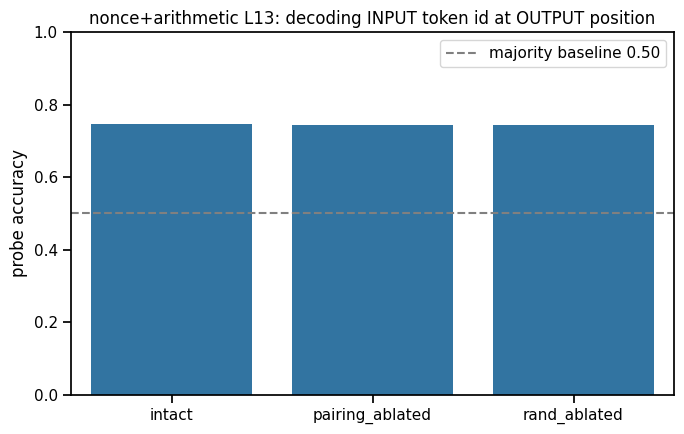

In [8]:
fig, ax = plt.subplots(figsize=(7,4.5))
order=['intact','pairing_ablated','rand_ablated']
sns.barplot(res, x='condition', y='input_decode_acc', order=order, ax=ax)
mb = res['majority_baseline'].iloc[0]
ax.axhline(mb, ls='--', color='gray', label=f'majority baseline {mb:.2f}')
ax.set(title=f'{DATASET} L{PROBE_LAYER}: decoding INPUT token id at OUTPUT position',
       ylabel='probe accuracy', xlabel='', ylim=(0,1)); ax.legend()
plt.tight_layout(); plt.show()

## Read it
- **intact high, pairing_ablated drops, rand_ablated stays high** -> pairing heads carry
  input identity to the output position. New hypothesis CONFIRMED, clean anchor.
- **all three similar** -> input gets to the output position some other way (not pairing).
- **all near majority baseline** -> input identity isn't at the output position; rethink.
- The position reference should stay decodable in all conditions (sanity check the probe works).

Try a few PROBE_LAYER values — the effect should localize where pairing heads write.

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from utils.heads import select_scope

pairing    = select_scope(ms, SCOPE)['pairing']
rand_heads = select_scope(ms, SCOPE)['pairing_rand']

def task_discrim(headname):
    sel = (meta.headname==headname).values
    X = V[sel]; tk = meta.task[sel].values
    Xn = X/(np.linalg.norm(X,axis=1,keepdims=True)+1e-9)
    tasks_u = np.unique(tk)
    cents = {t: Xn[tk==t].mean(0) for t in tasks_u}
    cents = {t: c/(np.linalg.norm(c)+1e-9) for t,c in cents.items()}
    within = np.mean([Xn[i] @ cents[tk[i]] for i in range(len(Xn))])
    C = np.stack([cents[t] for t in tasks_u]); G = C @ C.T; n=len(tasks_u)
    between = (G.sum()-np.trace(G))/(n*(n-1))
    return within, between, within-between

rows=[]
for hn in sorted(set(f'{l}.{h}' for l,h in pairing) | set(f'{l}.{h}' for l,h in rand_heads),
                 key=lambda s:(int(s.split('.')[0]),int(s.split('.')[1]))):
    if hn not in set(meta.headname): continue
    w,b,s = task_discrim(hn)
    grp = 'pairing' if tuple(map(int,hn.split('.'))) in set(pairing) else 'random'
    rows.append({'head':hn,'group':grp,'within':w,'between':b,'separation':s})
D=pd.DataFrame(rows)
print(D.groupby('group')[['within','between','separation']].mean().round(3).to_string())
fig,ax=plt.subplots(figsize=(7,4.5))
sns.boxplot(D, x='group', y='separation', ax=ax)
sns.stripplot(D, x='group', y='separation', color='k', size=3, alpha=.5, ax=ax)
ax.axhline(0,color='gray',lw=.8)
ax.set(title='task separation of OV writes (within−between cosine): pairing vs random',
       ylabel='within − between task cosine')
plt.tight_layout(); plt.show()

NameError: name 'meta' is not defined